# Greenfilling trade-offs

An exploratory look at the full 28-day campaign. The goal is to get a feel for what greenfilling (optimizing either carbon or water) does to the environmental footprint and to job performance, compared to plain EASY backfilling on the same workload and the same environmental window.

The campaign samples 36 windows of about four weeks each, spread across three grids (DE, FR, PL) and the four seasons, and runs four workload scenarios on every window: a `stress` and a `slack` extract from each of two machines, Mustang and Trinity. These labels describe how the extracts were selected within each source trace. They are not assumed to be equivalent across machines. The analysis below keeps all four scenarios separate so the comparison stays paired and avoids generalizing from one extract.

This analysis looks at replay jobs separately before saying anything about performance.

Every figure is rendered at IEEE double-column width and exported to `analysis/figures` as a vector PDF with embedded fonts and as 600 dpi PNG line art.

## Load Campaign Metadata

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

import campaign_analysis as ca

pd.set_option("display.max_columns", 120)
ca.apply_paper_style()

root = Path.cwd()
if not (root / "experiments").exists():
    root = root.parent

campaign_path = root / "experiments" / "experiments.toml"
windows_path = root / "intensities" / "windows.csv"
out_dir = root / "experiments" / "out"
figures_dir = root / "analysis" / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

print(f"campaign: {campaign_path}")
print(f"windows: {windows_path}")
print(f"outputs: {out_dir}")
print(f"figures: {figures_dir}")

campaign: /Users/lucas/ws/doct/experimental-artifacts/experiments/experiments.toml
windows: /Users/lucas/ws/doct/experimental-artifacts/intensities/windows.csv
outputs: /Users/lucas/ws/doct/experimental-artifacts/experiments/out
figures: /Users/lucas/ws/doct/experimental-artifacts/analysis/figures


In [2]:
campaign_df, windows = ca.load_campaign(campaign_path, windows_path)

display(campaign_df.head())
display(windows.head())

,name,workload,platform,environmental_trace,variant_name,variant_options,variant,objective,workload_label,dataset,regime,zone,start_date
0,easy_bf_mustang_slack_DE_2019-02-04,../workloads and platforms/mustang_slack.json,../workloads and platforms/mustang.xml,../intensities/traces/DE_2019-02-04.csv,easy_bf,,easy_bf,baseline,mustang_slack,mustang,slack,DE,2019-02-04
1,easy_bf_mustang_slack_DE_2019-07-01,../workloads and platforms/mustang_slack.json,../workloads and platforms/mustang.xml,../intensities/traces/DE_2019-07-01.csv,easy_bf,,easy_bf,baseline,mustang_slack,mustang,slack,DE,2019-07-01
2,easy_bf_mustang_slack_DE_2019-11-25,../workloads and platforms/mustang_slack.json,../workloads and platforms/mustang.xml,../intensities/traces/DE_2019-11-25.csv,easy_bf,,easy_bf,baseline,mustang_slack,mustang,slack,DE,2019-11-25
3,easy_bf_mustang_slack_DE_2021-04-05,../workloads and platforms/mustang_slack.json,../workloads and platforms/mustang.xml,../intensities/traces/DE_2021-04-05.csv,easy_bf,,easy_bf,baseline,mustang_slack,mustang,slack,DE,2021-04-05
4,easy_bf_mustang_slack_DE_2021-06-07,../workloads and platforms/mustang_slack.json,../workloads and platforms/mustang.xml,../intensities/traces/DE_2021-06-07.csv,easy_bf,,easy_bf,baseline,mustang_slack,mustang,slack,DE,2021-06-07


,zone,file,start_date,season,year,mean_carbon,mean_water,swing_carbon,swing_water
0,DE,traces/DE_2019-02-04.csv,2019-02-04,winter,2019,353.0408,1.5175,0.3195,0.3156
1,DE,traces/DE_2019-07-01.csv,2019-07-01,summer,2019,329.5072,1.7950,0.5157,0.5225
2,DE,traces/DE_2019-11-25.csv,2019-11-25,autumn,2019,310.1717,1.4219,0.3846,0.2939
3,DE,traces/DE_2021-04-05.csv,2021-04-05,spring,2021,310.8788,1.4464,0.5105,0.4568
4,DE,traces/DE_2021-06-07.csv,2021-06-07,summer,2021,354.3108,1.9153,0.5170,0.5608


## Check Result Completeness

In [3]:
result_files = ca.check_completeness(campaign_df, out_dir)

display(ca.completeness_summary(result_files))

missing = ca.missing_results(result_files)
if missing.empty:
    print(f"All {len(result_files)} experiments have schedule and job outputs.")
else:
    display(missing.sort_values(["variant", "workload_label", "zone", "start_date"]))

has_directory  has_schedule  has_jobs  \
variant             workload_label                                          
easy_bf             mustang_slack              36            36        36   
                    mustang_stress             36            36        36   
                    trinity_slack              36            36        36   
                    trinity_stress             36            36        36   
greenfilling_carbon mustang_slack              36            36        36   
                    mustang_stress             36            36        36   
                    trinity_slack              36            36        36   
                    trinity_stress             36            36        36   
greenfilling_water  mustang_slack              36            36        36   
                    mustang_stress             36            36        36   
                    trinity_slack              36            36        36   
                    trinity_stress             36            36        36   

                                    has_environmental_footprint  
variant             workload_label                               
easy_bf             mustang_slack                            36  
                    mustang_stress                           36  
                    trinity_slack                            36  
                    trinity_stress                           36  
greenfilling_carbon mustang_slack                            36  
                    mustang_stress                           36  
                    trinity_slack                            36  
                    trinity_stress                           36  
greenfilling_water  mustang_slack                            36  
                    mustang_stress                           36  
                    trinity_slack                            36  
                    trinity_stress                           36

All 432 experiments have schedule and job outputs.


## Load Result Tables

This section builds the reusable tables for the rest of the notebook. `schedules` has one row per experiment. `jobs` has one row per simulated job and labels each job as either `context` or `replay`.

For slowdown, the main metric is average bounded slowdown with a 10-second floor: `max(turnaround_time / max(execution_time, 10), 1)`. This keeps very short jobs from dominating the comparison while preserving the direction of the performance trade-off.

In [4]:
schedules, jobs = ca.load_results(campaign_df, result_files, out_dir, windows)

print(f"schedules: {len(schedules)} rows")
print(f"jobs: {len(jobs)} rows")

display(schedules[["name", "variant", "zone", "start_date", "season", "nb_jobs"]].head())
print(f"bounded slowdown floor: {ca.BOUNDED_SLOWDOWN_FLOOR_SECONDS:g} seconds")
display(jobs[["name", "job_id", "job_kind", "waiting_time", "stretch", "bounded_slowdown"]].head())

schedules: 432 rows
jobs: 2608740 rows


,name,variant,zone,start_date,season,nb_jobs
0,easy_bf_mustang_slack_DE_2019-02-04,easy_bf,DE,2019-02-04,winter,10745
1,easy_bf_mustang_slack_DE_2019-07-01,easy_bf,DE,2019-07-01,summer,10745
2,easy_bf_mustang_slack_DE_2019-11-25,easy_bf,DE,2019-11-25,autumn,10745
3,easy_bf_mustang_slack_DE_2021-04-05,easy_bf,DE,2021-04-05,spring,10745
4,easy_bf_mustang_slack_DE_2021-06-07,easy_bf,DE,2021-06-07,summer,10745


bounded slowdown floor: 10 seconds


,name,job_id,job_kind,waiting_time,stretch,bounded_slowdown
0,easy_bf_mustang_slack_DE_2019-02-04,ctx_queued1,context,0.0,1.000000,1.000000
1,easy_bf_mustang_slack_DE_2019-02-04,ctx_queued2,context,5.0,2.000000,1.000000
2,easy_bf_mustang_slack_DE_2019-02-04,ctx_queued12,context,0.0,1.000000,1.000000
3,easy_bf_mustang_slack_DE_2019-02-04,ctx_queued36,context,10.0,1.555556,1.555556
4,easy_bf_mustang_slack_DE_2019-02-04,ctx_queued17,context,0.0,1.000000,1.000000


In [5]:
job_metrics = ca.build_job_metrics(jobs)

display(ca.summarize_job_metrics(job_metrics))
display(job_metrics.head())

runs  jobs_per_run  \
workload_label variant             job_kind                       
mustang_slack  easy_bf             context     36          62.0   
                                   replay      36       10683.0   
               greenfilling_carbon context     36          62.0   
                                   replay      36       10683.0   
               greenfilling_water  context     36          62.0   
                                   replay      36       10683.0   
mustang_stress easy_bf             context     36          31.0   
                                   replay      36        5089.0   
               greenfilling_carbon context     36          31.0   
                                   replay      36        5089.0   
               greenfilling_water  context     36          31.0   
                                   replay      36        5089.0   
trinity_slack  easy_bf             replay      36        4622.0   
               greenfilling_carbon replay      36        4622.0   
               greenfilling_water  replay      36        4622.0   
trinity_stress easy_bf             context     36         131.0   
                                   replay      36        3537.0   
               greenfilling_carbon context     36         131.0   
                                   replay      36        3537.0   
               greenfilling_water  context     36         131.0   
                                   replay      36        3537.0   

                                             median_bounded_slowdown  
workload_label variant             job_kind                           
mustang_slack  easy_bf             context                     7.032  
                                   replay                     65.532  
               greenfilling_carbon context                     7.586  
                                   replay                    277.580  
               greenfilling_water  context                     7.531  
                                   replay                    267.678  
mustang_stress easy_bf             context                   877.753  
                                   replay                    151.974  
               greenfilling_carbon context                   878.015  
                                   replay                    417.904  
               greenfilling_water  context                   877.767  
                                   replay                    397.449  
trinity_slack  easy_bf             replay                      2.473  
               greenfilling_carbon replay                      7.669  
               greenfilling_water  replay                      7.703  
trinity_stress easy_bf             context                     6.607  
                                   replay                      2.486  
               greenfilling_carbon context                     7.441  
                                   replay                      8.119  
               greenfilling_water  context                     6.615  
                                   replay                      7.788

,name,variant,workload_label,zone,start_date,job_kind,jobs,median_waiting_time,p95_waiting_time,mean_bounded_slowdown
0,easy_bf_mustang_slack_DE_2019-02-04,easy_bf,mustang_slack,DE,2019-02-04,context,62,10.0,56544.85,7.031552
1,easy_bf_mustang_slack_DE_2019-02-04,easy_bf,mustang_slack,DE,2019-02-04,replay,10683,12.0,53456.80,65.532318
2,easy_bf_mustang_slack_DE_2019-07-01,easy_bf,mustang_slack,DE,2019-07-01,context,62,10.0,56544.85,7.031552
3,easy_bf_mustang_slack_DE_2019-07-01,easy_bf,mustang_slack,DE,2019-07-01,replay,10683,12.0,53456.80,65.532318
4,easy_bf_mustang_slack_DE_2019-11-25,easy_bf,mustang_slack,DE,2019-11-25,context,62,10.0,56544.85,7.031552


## Paired comparison: greenfilling versus EASY

The traces differ by country and window, and there are four workloads (two machines, each with a stress and a slack regime), so I compare paired by `(workload, zone, start_date)`: each greenfilling run sits next to the EASY run from the same workload, platform, and window. Most deltas below are percentages relative to EASY in that same workload and window. Median waiting time is an absolute difference in seconds because a zero-second EASY median would make a relative change undefined. Results are kept split by workload throughout so the four workloads are never averaged together.

For performance I look at replay jobs only. Context jobs are the initial backlog, and folding them in would mix warm-up with the behavior I actually care about.

In [6]:
run_metrics = ca.build_run_metrics(schedules, job_metrics)

display(run_metrics.head())

,name,variant,workload_label,zone,start_date,season,swing_carbon,swing_water,total_carbon_footprint,total_carbon_operational,total_water_footprint,total_water_offsite,consumed_joules,makespan,consumed_energy_kwh,energy_weighted_carbon_intensity,energy_weighted_water_intensity,replay_jobs,replay_median_waiting_time,replay_p95_waiting_time,replay_mean_bounded_slowdown
0,easy_bf_mustang_slack_DE_2019-02-04,easy_bf,mustang_slack,DE,2019-02-04,winter,0.3195,0.3156,1.084528e+08,1.084528e+08,466098.524103,466098.524103,1.101390e+12,2467562.0,305941.542147,354.488741,1.523489,10683,12.0,53456.8,65.532318
1,easy_bf_mustang_slack_DE_2019-07-01,easy_bf,mustang_slack,DE,2019-07-01,summer,0.5157,0.5225,1.025825e+08,1.025825e+08,558514.573227,558514.573227,1.101390e+12,2467562.0,305941.542147,335.300841,1.825560,10683,12.0,53456.8,65.532318
2,easy_bf_mustang_slack_DE_2019-11-25,easy_bf,mustang_slack,DE,2019-11-25,autumn,0.3846,0.2939,9.562338e+07,9.562338e+07,439218.659147,439218.659147,1.101390e+12,2467562.0,305941.542147,312.554419,1.435629,10683,12.0,53456.8,65.532318
3,easy_bf_mustang_slack_DE_2021-04-05,easy_bf,mustang_slack,DE,2021-04-05,spring,0.5105,0.4568,9.553711e+07,9.553711e+07,445302.301230,445302.301230,1.101390e+12,2467562.0,305941.542147,312.272438,1.455514,10683,12.0,53456.8,65.532318
4,easy_bf_mustang_slack_DE_2021-06-07,easy_bf,mustang_slack,DE,2021-06-07,summer,0.5170,0.5608,1.104293e+08,1.104293e+08,596156.204934,596156.204934,1.101390e+12,2467562.0,305941.542147,360.949009,1.948595,10683,12.0,53456.8,65.532318


The table below summarizes paired deltas across the 36 windows. Percentages are relative to EASY in the same window, except median waiting time, which is an absolute difference in seconds.

In [7]:
paired_comparisons = ca.build_paired_comparisons(run_metrics)

display(ca.summarize_paired(paired_comparisons))
display(
    paired_comparisons[
        ["greenfilling_variant", "workload_label", "zone", "season", "start_date"]
        + ca.DELTA_COLUMNS[1:]
    ].head()
)

total_carbon_footprint_delta_pct        \
                                                              median   min   
workload_label greenfilling_variant                                          
mustang_slack  greenfilling_carbon                             -0.07 -0.36   
               greenfilling_water                              -0.05 -0.19   
mustang_stress greenfilling_carbon                              0.01 -0.40   
               greenfilling_water                               0.04 -0.28   
trinity_slack  greenfilling_carbon                             -0.01 -0.16   
               greenfilling_water                              -0.01 -0.18   
trinity_stress greenfilling_carbon                              0.00 -0.02   
               greenfilling_water                              -0.00 -0.02   

                                          total_water_footprint_delta_pct  \
                                      max                          median   
workload_label greenfilling_variant                                         
mustang_slack  greenfilling_carbon   0.41                           -0.05   
               greenfilling_water    0.10                           -0.03   
mustang_stress greenfilling_carbon   0.68                            0.02   
               greenfilling_water    0.65                            0.01   
trinity_slack  greenfilling_carbon   0.14                            0.00   
               greenfilling_water    0.06                           -0.01   
trinity_stress greenfilling_carbon   0.01                           -0.00   
               greenfilling_water    0.01                           -0.00   

                                                consumed_energy_kwh_delta_pct  \
                                      min   max                        median   
workload_label greenfilling_variant                                             
mustang_slack  greenfilling_carbon  -0.25  0.30                          0.00   
               greenfilling_water   -0.15  0.07                          0.00   
mustang_stress greenfilling_carbon  -0.27  0.39                          0.04   
               greenfilling_water   -0.31  0.30                          0.04   
trinity_slack  greenfilling_carbon  -0.07  0.10                          0.00   
               greenfilling_water   -0.06  0.09                          0.00   
trinity_stress greenfilling_carbon  -0.02  0.01                          0.00   
               greenfilling_water   -0.02  0.02                          0.00   

                                                 \
                                      min   max   
workload_label greenfilling_variant               
mustang_slack  greenfilling_carbon   0.00  0.00   
               greenfilling_water    0.00  0.00   
mustang_stress greenfilling_carbon   0.02  0.06   
               greenfilling_water    0.01  0.06   
trinity_slack  greenfilling_carbon  -0.00  0.01   
               greenfilling_water   -0.00  0.01   
trinity_stress greenfilling_carbon  -0.00  0.00   
               greenfilling_water   -0.00  0.00   

                                    energy_weighted_carbon_intensity_delta_pct  \
                                                                        median   
workload_label greenfilling_variant                                              
mustang_slack  greenfilling_carbon                                       -0.07   
               greenfilling_water                                        -0.05   
mustang_stress greenfilling_carbon                                       -0.04   
               greenfilling_water                                        -0.00   
trinity_slack  greenfilling_carbon                                       -0.01   
               greenfilling_water                                        -0.01   
trinity_stress greenfilling_carbon                                        0.00   
               greenfilling_water                      

,greenfilling_variant,workload_label,zone,season,start_date,total_carbon_footprint_delta_pct,total_water_footprint_delta_pct,consumed_energy_kwh_delta_pct,energy_weighted_carbon_intensity_delta_pct,energy_weighted_water_intensity_delta_pct,makespan_delta_pct,replay_median_waiting_time_delta_seconds,replay_p95_waiting_time_delta_pct,replay_mean_bounded_slowdown_delta_pct
0,greenfilling_carbon,mustang_slack,DE,winter,2019-02-04,0.030107,0.023351,2.910939e-12,0.030107,0.023351,0.0,7762.0,50.558582,477.261614
1,greenfilling_carbon,mustang_slack,DE,summer,2019-07-01,-0.246137,-0.192239,4.014432e-12,-0.246137,-0.192239,0.0,9144.0,61.187538,417.682324
2,greenfilling_carbon,mustang_slack,DE,autumn,2019-11-25,-0.043192,-0.037777,1.693291e-12,-0.043192,-0.037777,0.0,4227.0,57.304964,312.320451
3,greenfilling_carbon,mustang_slack,DE,spring,2021-04-05,-0.022364,-0.010103,3.633917e-12,-0.022364,-0.010103,0.0,7101.0,57.845026,374.138067
4,greenfilling_carbon,mustang_slack,DE,summer,2021-06-07,-0.229301,-0.185811,3.690995e-12,-0.229301,-0.185811,0.0,7576.0,54.905082,315.336456


## Distributions of deltas versus EASY

Each point is one sampled window, and the box just summarizes the spread across windows. Within each objective the four workloads sit side by side and are distinguished with black hatches on white boxes. The line at zero is "no change from EASY." Below zero means lower footprint or slowdown than EASY.

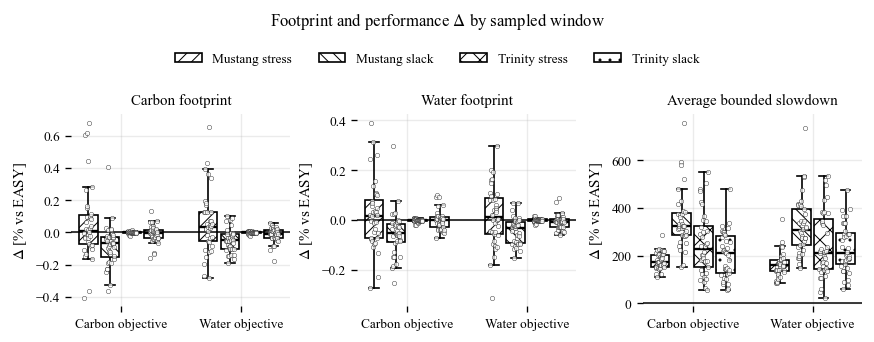

In [8]:
delta_fig, _ = ca.plot_deltas_vs_easy(paired_comparisons)
ca.export_figure(delta_fig, figures_dir, "greenfilling_deltas_vs_easy");

For the carbon objective, the median carbon-footprint deltas were +0.008% for Mustang stress, -0.068% for Mustang slack, +0.001% for Trinity stress, and -0.005% for Trinity slack. Carbon footprint was lower than EASY in 17 of 36 Mustang stress windows and 30 of 36 Mustang slack windows. For the water objective, the median water-footprint deltas were +0.014% for Mustang stress, -0.031% for Mustang slack, -0.0003% for Trinity stress, and -0.007% for Trinity slack. Water footprint was lower than EASY in 16 of 36 Mustang stress windows and 29 of 36 Mustang slack windows.

Average bounded slowdown increased in all 288 Greenfilling-to-EASY pairs. For the carbon objective, the median deltas were +174.98% for Mustang stress, +323.58% for Mustang slack, +226.56% for Trinity stress, and +210.13% for Trinity slack. For the water objective, the median deltas were +161.52% for Mustang stress, +308.47% for Mustang slack, +213.25% for Trinity stress, and +211.51% for Trinity slack. Across individual windows, average bounded-slowdown deltas ranged from +24.45% to +757.19%.

## Environmental saving versus performance penalty

The boxes above show each axis on its own. The next two scatters try to show the trade-off directly: one point per window, environmental saving on x, replay slowdown penalty on y. Rows are the four workloads and columns are zones. Roughly, lower-right is the nice region (less footprint, no extra slowdown), upper-right is a real trade-off, and left of zero means the footprint got worse in that window.

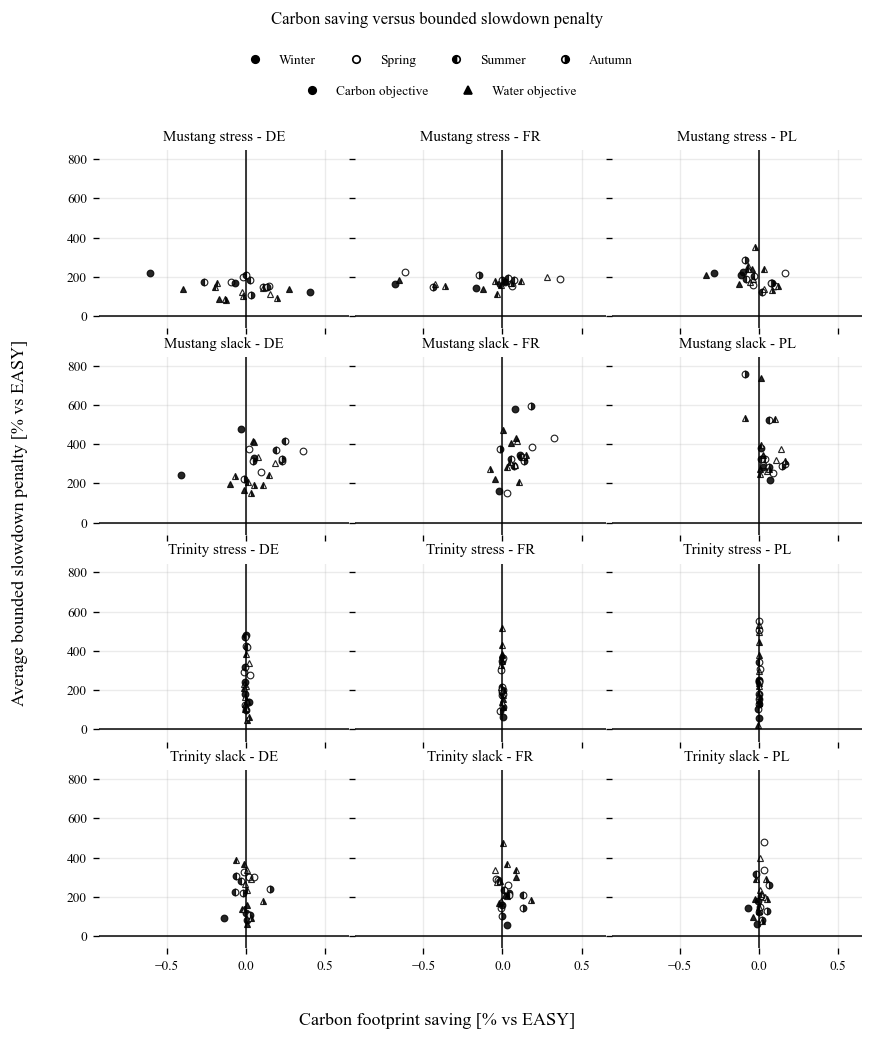

In [9]:
carbon_tradeoff_fig, _ = ca.plot_tradeoff_scatter(
    paired_comparisons,
    "total_carbon_footprint_delta_pct",
    "Carbon footprint saving [% vs EASY]",
    "Carbon saving versus bounded slowdown penalty",
)
ca.export_figure(carbon_tradeoff_fig, figures_dir, "carbon_saving_vs_slowdown");

Carbon saving on the x-axis. I keep the water-objective points in too, since a scheduler tuned for one signal might still move the other.

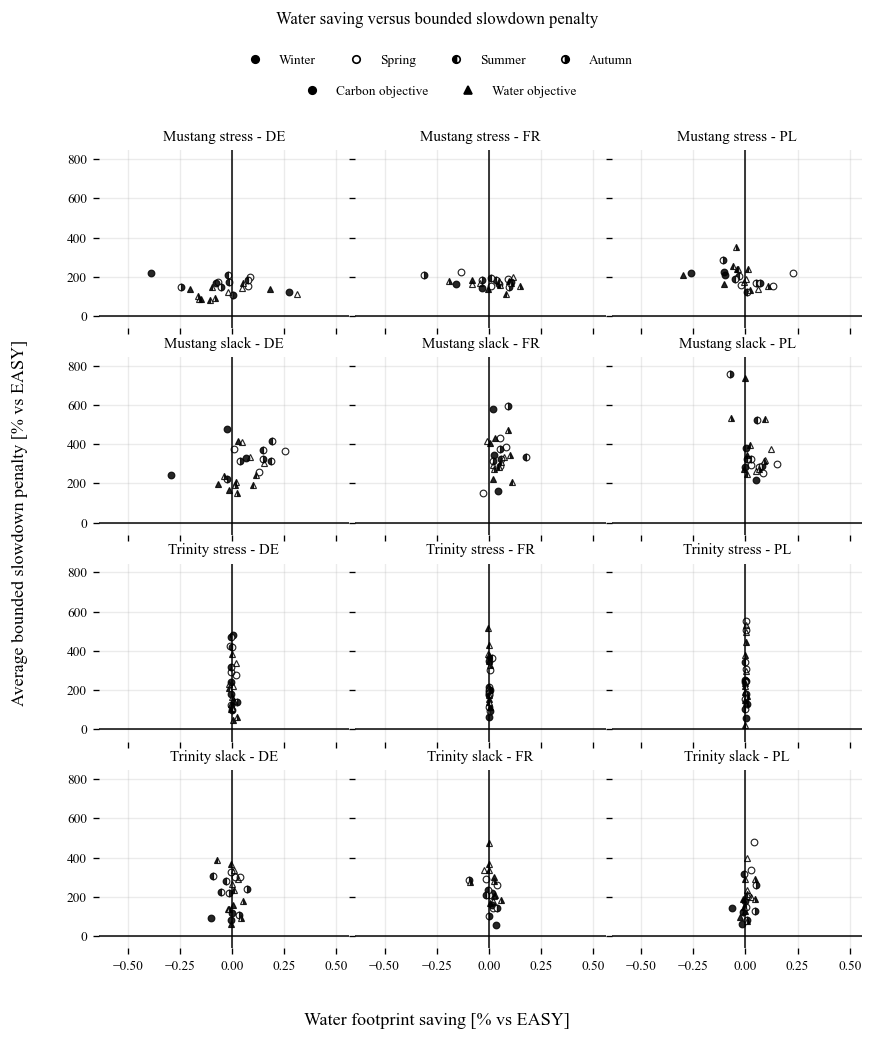

In [10]:
water_tradeoff_fig, _ = ca.plot_tradeoff_scatter(
    paired_comparisons,
    "total_water_footprint_delta_pct",
    "Water footprint saving [% vs EASY]",
    "Water saving versus bounded slowdown penalty",
)
ca.export_figure(water_tradeoff_fig, figures_dir, "water_saving_vs_slowdown");

Same view for water. Putting it beside the carbon figure gives a rough sense of whether optimizing one signal helps or fights the other.

## Energy and intensity exposure

A footprint change can come from consuming a different amount of energy, encountering a different intensity while consuming it, or both. The next figure separates these mechanisms. Consumed energy covers the whole simulated platform. Effective carbon and water intensities are the operational carbon and off-site water footprints divided by that energy. They are energy-weighted averages over the schedule, not simple averages over time.

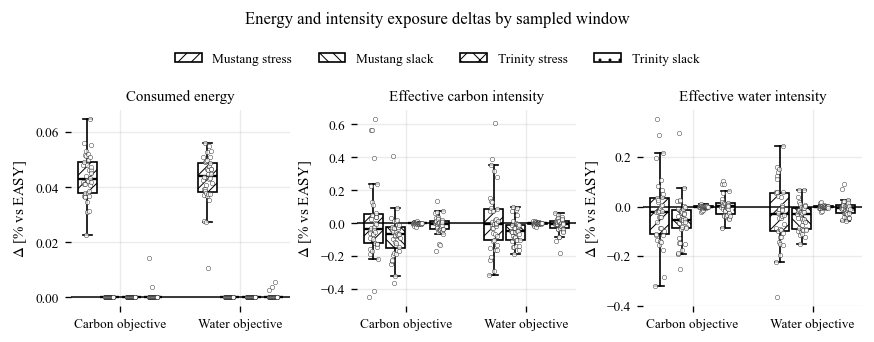

In [11]:
energy_exposure_fig, _ = ca.plot_energy_exposure_deltas(paired_comparisons)
ca.export_figure(energy_exposure_fig, figures_dir, "energy_exposure_deltas");

Energy is unchanged to numerical precision at the median for Mustang slack and both Trinity scenarios, so their target-footprint medians match their effective-intensity medians. Mustang stress is different: consumed energy rises by about 0.043% for carbon Greenfilling and 0.044% for water Greenfilling, while effective target intensity falls by about 0.037% and 0.032%. The extra energy slightly outweighs that exposure improvement, leaving a small increase in total target footprint. This decomposition is consistent with an exposure effect being offset by schedule extension, but it remains a whole-platform result rather than a job-only energy attribution.

## Does swing line up with the savings?

,objective,workload_label,observations,pearson_r
0,carbon,pooled,144,0.079
1,carbon,mustang_stress,36,-0.047
2,carbon,mustang_slack,36,0.432
3,carbon,trinity_stress,36,0.275
4,carbon,trinity_slack,36,-0.012
5,water,pooled,144,0.247
6,water,mustang_stress,36,0.317
7,water,mustang_slack,36,0.585
8,water,trinity_stress,36,-0.087
9,water,trinity_slack,36,0.044


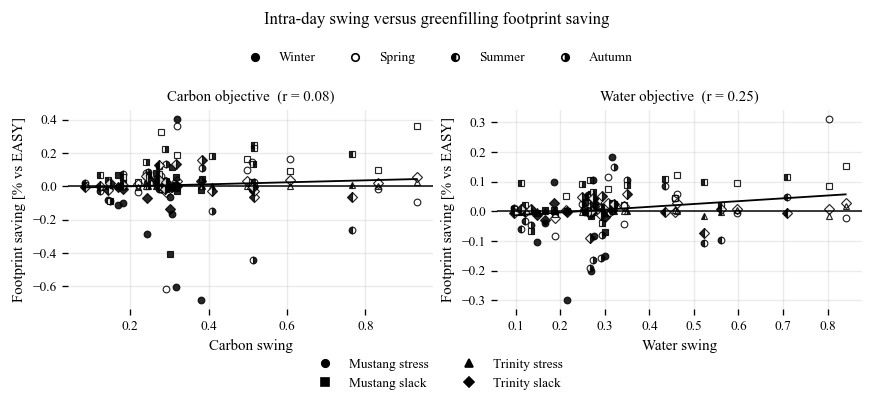

In [12]:
display(ca.summarize_swing_correlations(paired_comparisons))
swing_fig, _ = ca.plot_swing_relationship(paired_comparisons)
ca.export_figure(swing_fig, figures_dir, "swing_vs_footprint_saving");

`swing` is the mean daily peak-to-trough range of a signal over the window mean, so it is a rough proxy for daily variation. The pooled association with target saving is weak for carbon (r = 0.079) and somewhat larger for water (r = 0.247), but every environmental window is reused by four workload scenarios. The per-scenario correlations are not consistent. Mustang slack is positive for carbon (0.432) and water (0.585), while Mustang stress is -0.047 and 0.317. Trinity stress is 0.275 and -0.087, and Trinity slack is -0.012 and 0.044. The current case studies therefore do not show that higher swing reliably produces larger savings.

## Takeaway

Across these four selected workload scenarios, Greenfilling changes the target footprint by less than 0.1% at the median. Mustang slack shows the most consistent reductions. Mustang stress shows a small effective-intensity improvement that is offset by extra platform energy. Both Trinity scenarios remain very close to zero environmentally.

The performance effects are larger and consistent in direction. P95 waiting time and mean bounded slowdown increase in every paired comparison, including the Trinity scenarios whose median waiting time stays at zero. The carbon and water objectives behave similarly at this scale.

These results suggest that this event-driven backfilling gate has limited environmental leverage in the selected scenarios while imposing substantial delay on some jobs. They do not establish a general effect for Mustang, Trinity, other workloads, or other platform assumptions.